In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset (Make sure the CSV file is in the same directory as your notebook)
df = pd.read_csv('5-Social_Network_Ads.csv')

# Display the first 5 rows
display(df.head())

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Extracting features (Age and Estimated Salary) and target variable (Purchased)
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (400, 2)
Shape of y: (400,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (300, 2)
Testing data shape: (100, 2)


In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Fit and transform the training data, but only transform the testing data
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression classifier
classifier = LogisticRegression(random_state=42)

# Train the model
classifier.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [7]:
# Predict the results on the test set
y_pred = classifier.predict(X_test)

# Compare actual vs predicted for the first 10 values
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison.head(10))

,Actual,Predicted
209,0,0
280,1,1
33,0,0
210,1,1
93,0,0
84,0,0
329,1,1
94,0,0
266,0,0
126,0,0


Confusion Matrix:
 [[61  2]
 [12 25]]


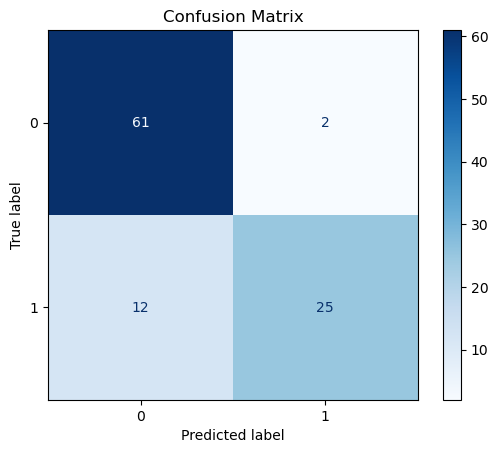

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plotting the Confusion Matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [9]:
# Extracting True Negatives, False Positives, False Negatives, True Positives
TN, FP, FN, TP = cm.ravel()

print(f"True Positives (TP): {TP} - (Correctly predicted Purchases)")
print(f"False Positives (FP): {FP} - (Incorrectly predicted Purchases)")
print(f"True Negatives (TN): {TN} - (Correctly predicted Non-Purchases)")
print(f"False Negatives (FN): {FN} - (Incorrectly predicted Non-Purchases)")

True Positives (TP): 25 - (Correctly predicted Purchases)
False Positives (FP): 2 - (Incorrectly predicted Purchases)
True Negatives (TN): 61 - (Correctly predicted Non-Purchases)
False Negatives (FN): 12 - (Incorrectly predicted Non-Purchases)


In [10]:
# 1. Accuracy: Overall correctness of the model
accuracy = (TP + TN) / (TP + TN + FP + FN)

# 2. Error Rate: Proportion of incorrect predictions
error_rate = (FP + FN) / (TP + TN + FP + FN)
# Alternatively: error_rate = 1 - accuracy

# 3. Precision: Accuracy of positive predictions
precision = TP / (TP + FP)

# 4. Recall (Sensitivity): Proportion of actual positives correctly identified
recall = TP / (TP + FN)

print("--- Evaluation Metrics ---")
print(f"Accuracy   : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Error Rate : {error_rate:.4f} ({error_rate * 100:.2f}%)")
print(f"Precision  : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall     : {recall:.4f} ({recall * 100:.2f}%)")

--- Evaluation Metrics ---
Accuracy   : 0.8600 (86.00%)
Error Rate : 0.1400 (14.00%)
Precision  : 0.9259 (92.59%)
Recall     : 0.6757 (67.57%)


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

print("Metrics using sklearn built-in functions:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Metrics using sklearn built-in functions:
Accuracy : 0.8600
Precision: 0.9259
Recall   : 0.6757

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100

